# AI-Driven Marketing – Data Analysis
### Customer Profiling & Churn Prediction

**Overview of Phases:**
- **Phase I** – Data Loading & Preprocessing
- **Phase II** – Pattern Identification (Spending, Timing, Order Source)
- **Phase III** – Customer Profiling
- **Phase IV** – Churn Prediction via RFM Clustering

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


## PHASE I – Data Preprocessing

Two datasets are used:
- `Campbell_Menu_Data_-_2.xlsx` – Menu items catalogue
- `Marketing_data.csv` – Transaction-level order records


In [10]:
df_items  = pd.read_excel("data/task1/MenuData.xlsx")
df_market = pd.read_csv("data/task1/Marketing_data.csv")

print("df_items  shape:", df_items.shape)
print("df_market shape:", df_market.shape)


df_items  shape: (325, 7)
df_market shape: (12545, 17)


In [11]:
print("=== df_items columns ===")
print(df_items.columns.tolist())
display(df_items.head(3))

=== df_items columns ===
['id', 'itemName', 'itemDescription', 'itemPrice', 'preparationTime', 'Category', 'Allergens']


,id,itemName,itemDescription,itemPrice,preparationTime,Category,Allergens
0,1,Around the World,One of each of our signature food flights incl...,17.50,15.0,Signature Flights,"Dairy , Egg, Gluten, Nitrates, Tree Nuts, Pean..."
1,2,Slider Flight,"Bacon cheeseburger with flight sauce, buffalo ...",19.95,10.0,Signature Flights,"Dairy , Egg, Gluten"
2,3,Taco Flight,"Steak, chicken, and carnitas, served in warm t...",17.95,11.0,Signature Flights,"Dairy , Egg"


In [12]:
print("=== df_market columns ===")
print(df_market.columns.tolist())
display(df_market.head(3))


=== df_market columns ===
['Unnamed: 0', 'Menu Item', 'Modifiers', 'Price', 'Qty', 'Discount', 'Net', 'Tax', 'Total', 'Voided?', 'Reason', 'Refund Qty', 'Refund', 'Last 4 Card Digits', 'Order Date', 'Tip', 'Gratuity']


,Unnamed: 0,Menu Item,Modifiers,Price,Qty,Discount,Net,Tax,Total,Voided?,Reason,Refund Qty,Refund,Last 4 Card Digits,Order Date,Tip,Gratuity
0,0,Margarita Rock Flight,Salt,$24.00,1.0,$0.00,$24.00,$2.250,$26.25,False,NaN,0,$0.00,3108.0,2023-12-08 18:46:00,$6.86,$45.71
1,1,Margarita Rock Flight,Salt,$24.00,1.0,$0.00,$24.00,$2.250,$26.25,False,NaN,0,$0.00,3108.0,2023-12-08 18:46:00,$6.86,$45.71
2,2,Mojito Flight,NaN,$24.00,1.0,$0.00,$24.00,$2.250,$26.25,False,NaN,0,$0.00,3108.0,2023-12-08 18:46:00,$6.86,$45.71


In [13]:
# ── Investigate item-name duplicates ─────────────────────────
duplicate_items = df_items[df_items['itemName'].duplicated(keep=False)]
print("Items That appeared more than once: \n\n" , duplicate_items['itemName'].unique())


dup_items = df_items[df_items['itemName'].duplicated(keep=False)]
print("\nDuplicate item names with their prices and categories:\n")
print(dup_items[['itemName', 'itemPrice', 'Category']].to_string())


Items That appeared more than once: 

 ['Jim Beam' 'Jim Beam Dbl' 805 'Bluemoon' 'Bada Bing' 'Elysian Space Dust'
 'Morena Mia' 'Hapas ipa' 'Voodoo Ranger' 'Draks']

Duplicate item names with their prices and categories:

               itemName  itemPrice                Category
103            Jim Beam       10.0                 Whiskey
119        Jim Beam Dbl       24.0         Whiskey Doubles
133            Jim Beam       12.0          Scotch/bourbon
145        Jim Beam Dbl       24.0  Scotch/bourbon Doubles
174                 805        8.0                    Beer
175            Bluemoon        8.0                    Beer
176           Bada Bing        8.0                    Beer
177  Elysian Space Dust        8.0                    Beer
178          Morena Mia        8.0                    Beer
179           Hapas ipa        8.0                    Beer
180       Voodoo Ranger        8.0                    Beer
187               Draks        0.0                    Beer
260        

**Observations:** :
- They are not identical in terms of prices and categories , meaning
    - We can't discard the duplicates 


In [14]:
# 1a. dealing with nan values in df_items
df_items['itemDescription'] = df_items['itemDescription'].fillna('NA')
df_items['Allergens']       = df_items['Allergens'].fillna('NA')
df_items['preparationTime'] = df_items['preparationTime'].fillna('NA')
df_items['Category']        = df_items['Category'].fillna('Unknown')

# Identify order source: "not in Pos" items came from some 'other' source, while the rest are from POS
df_items['Order Source'] = df_items['itemDescription'].apply(
    lambda d: 'Other Sources' if 'not in Pos' in str(d) else 'POS'
)

# Composite key for joining to transaction data
df_items['composite_key'] = (
    df_items['itemName'].astype(str) + '_$' +
    df_items['itemPrice'].astype(str)
)

print("df_items NaN counts after cleaning:")
print(df_items.isnull().sum())


df_items NaN counts after cleaning:
id                 0
itemName           0
itemDescription    0
itemPrice          0
preparationTime    0
Category           0
Allergens          0
Order Source       0
composite_key      0
dtype: int64


1b. Clean df_market

In [15]:
# remove $ and convert to numeric FIRST
currency_cols = ['Total', 'Tip', 'Gratuity', 'Discount', 'Refund']
for col in currency_cols:
    df_market[col] = pd.to_numeric(
        df_market[col].str.replace('$', '', regex=False), errors='coerce'
    )
df_market['Qty'] = pd.to_numeric(df_market['Qty'], errors='coerce')
df_market

,Unnamed: 0,Menu Item,Modifiers,Price,Qty,Discount,Net,Tax,Total,Voided?,Reason,Refund Qty,Refund,Last 4 Card Digits,Order Date,Tip,Gratuity
0,0,Margarita Rock Flight,Salt,$24.00,1.0,0.00,$24.00,$2.250,26.25,False,NaN,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
1,1,Margarita Rock Flight,Salt,$24.00,1.0,0.00,$24.00,$2.250,26.25,False,NaN,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
2,2,Mojito Flight,NaN,$24.00,1.0,0.00,$24.00,$2.250,26.25,False,NaN,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
3,3,Mojito Flight,NaN,$24.00,1.0,0.00,$24.00,$2.250,26.25,False,NaN,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
4,4,Mojito Flight,NaN,$24.00,1.0,0.00,$24.00,$2.250,26.25,False,NaN,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12540,1,Taco Flight,"Carnitas, Carnitas, Carnitas",$17.95,1.0,8.98,$8.97,$0.840,9.81,False,NaN,0,0.0,2215.0,2024-01-13 16:37:00,8.00,0.00
12541,0,Martini Flight,NaN,$24.00,1.0,0.00,$24.00,$2.250,26.25,False,NaN,0,0.0,9741.0,2024-01-13 17:25:00,7.00,0.00
12542,1,Gin Flight,NaN,$24.00,1.0,0.00,$24.00,$2.250,26.25,False,NaN,0,0.0,9741.0,2024-01-13 17:25:00,7.00,0.00
12543,2,Slider Flight,NaN,$19.95,1.0,0.00,$19.95,$1.870,21.82,False,NaN,0,0.0,9741.0,2024-01-13 17:25:00,7.00,0.00


In [16]:
for col in ['Total', 'Tip', 'Qty', 'Gratuity', 'Discount', 'Refund']:
    df_market[col] = df_market[col].fillna(0)
df_market['Reason']    = df_market['Reason'].fillna('NA')
df_market['Modifiers'] = df_market['Modifiers'].fillna('NA')
df_market.head(5)

,Unnamed: 0,Menu Item,Modifiers,Price,Qty,Discount,Net,Tax,Total,Voided?,Reason,Refund Qty,Refund,Last 4 Card Digits,Order Date,Tip,Gratuity
0,0,Margarita Rock Flight,Salt,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
1,1,Margarita Rock Flight,Salt,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
2,2,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
3,3,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71
4,4,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71


In [17]:
# extract month, yeat, hour from date
df_market['Order Date'] = pd.to_datetime(df_market['Order Date'])
df_market['Year']       = df_market['Order Date'].dt.year
df_market['Month']      = df_market['Order Date'].dt.month
df_market['Hour']       = df_market['Order Date'].dt.hour
df_market.head(5)


,Unnamed: 0,Menu Item,Modifiers,Price,Qty,Discount,Net,Tax,Total,Voided?,Reason,Refund Qty,Refund,Last 4 Card Digits,Order Date,Tip,Gratuity,Year,Month,Hour
0,0,Margarita Rock Flight,Salt,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18
1,1,Margarita Rock Flight,Salt,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18
2,2,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18
3,3,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18
4,4,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,NA,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18


In [18]:
# Rename Last 4 Card Digits to Customer ID - for clarity
df_market = df_market.rename(columns={'Last 4 Card Digits': 'Customer ID'})


In [19]:
# joining key for market data - create composite key to match with df_items
df_market['composite_key'] = (
    df_market['Menu Item'].astype(str) + '_' +
    df_market['Price'].astype(str)
)
df_market.head(5)

,Unnamed: 0,Menu Item,Modifiers,Price,Qty,Discount,Net,Tax,Total,Voided?,...,Refund Qty,Refund,Customer ID,Order Date,Tip,Gratuity,Year,Month,Hour,composite_key
0,0,Margarita Rock Flight,Salt,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,...,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18,Margarita Rock Flight_$24.00
1,1,Margarita Rock Flight,Salt,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,...,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18,Margarita Rock Flight_$24.00
2,2,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,...,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18,Mojito Flight_$24.00
3,3,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,...,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18,Mojito Flight_$24.00
4,4,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,...,0,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18,Mojito Flight_$24.00


In [20]:
# create Year-Month column for easier time-based analysis
df_market['Year-Month'] = df_market['Order Date'].dt.to_period('M')

print("df_market NaN counts after cleaning:")
print(df_market[['Total','Tip','Qty','Gratuity','Discount','Refund']].isnull().sum())
display(df_market.head(3))


df_market NaN counts after cleaning:
Total       0
Tip         0
Qty         0
Gratuity    0
Discount    0
Refund      0
dtype: int64


,Unnamed: 0,Menu Item,Modifiers,Price,Qty,Discount,Net,Tax,Total,Voided?,...,Refund,Customer ID,Order Date,Tip,Gratuity,Year,Month,Hour,composite_key,Year-Month
0,0,Margarita Rock Flight,Salt,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,...,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18,Margarita Rock Flight_$24.00,2023-12
1,1,Margarita Rock Flight,Salt,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,...,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18,Margarita Rock Flight_$24.00,2023-12
2,2,Mojito Flight,NA,$24.00,1.0,0.0,$24.00,$2.250,26.25,False,...,0.0,3108.0,2023-12-08 18:46:00,6.86,45.71,2023,12,18,Mojito Flight_$24.00,2023-12


---
## PHASE II – Identifying Patterns

Three dimensions analysed:
1. **Spending patterns** → Premium / Standard / Economy
2. **Activity timing** → Morning / Mid-day / Evening
3. **Order source** → POS vs. Other Sources 

### 2a – Spending Patterns

SpendingTotal per row = Qty × (Total + Tip + Gratuity − Discount)

it calculates how much money was spent on each order after considering the price of the items, tips, gratuity, and any discounts applied.

Calculate percentile-based thresholds. By using percentiles, we can identify the top 25% of spenders as "Premium", the next 25% as "Standard", and the bottom 50% as "Economy". This method allows us to adapt to the actual distribution of spending in our dataset, ensuring that our categories reflect customer behavior.

- **Premium**  → ≥ 75th percentile
- **Standard** → 50th–75th percentile
- **Economy**  → < 50th percentile

In [21]:
df_market['SpendingTotal'] = df_market['Qty'] * (
    df_market['Total'] + df_market['Tip'] + df_market['Gratuity'] - df_market['Discount']
)

# setting Percentile thresholds
premium_threshold  = df_market['SpendingTotal'].quantile(0.75)
standard_threshold = df_market['SpendingTotal'].quantile(0.50)
print(f"Premium threshold  (75th pct): ${premium_threshold:.2f}")
print(f"Standard threshold (50th pct): ${standard_threshold:.2f}")

def categorize_spending(value):
    if value >= premium_threshold:
        return 'Premium'
    elif value >= standard_threshold:
        return 'Standard'
    return 'Economy'

df_market['SpendingCategory'] = df_market['SpendingTotal'].apply(categorize_spending)
print("\nTransaction-level spending distribution:")
print(df_market['SpendingCategory'].value_counts())


Premium threshold  (75th pct): $42.34
Standard threshold (50th pct): $31.82

Transaction-level spending distribution:
SpendingCategory
Economy     6268
Standard    3139
Premium     3138
Name: count, dtype: int64


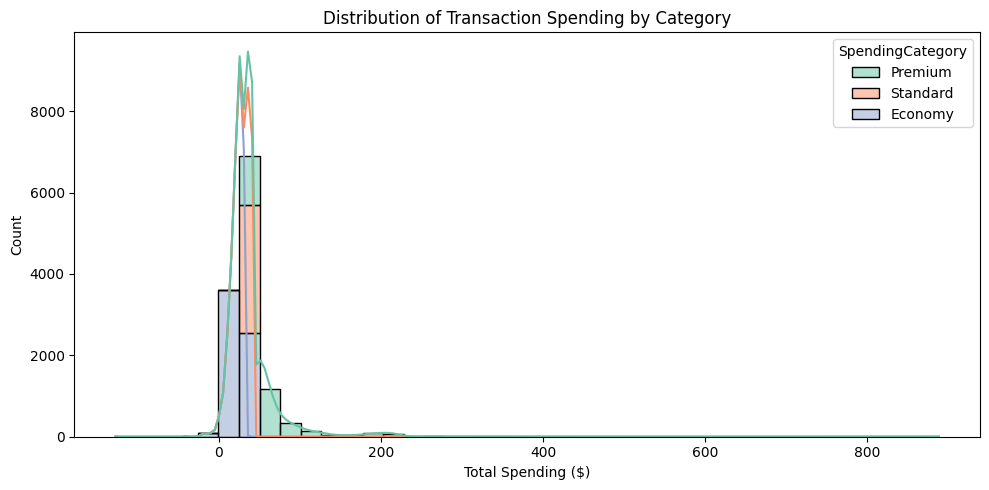

In [22]:
#  a histogram to see the distribution of total spendings
plt.figure(figsize=(10, 5))
sns.histplot(data=df_market, x='SpendingTotal', hue='SpendingCategory',
             multiple='stack', palette='Set2', bins=40, kde=True)
plt.title('Distribution of Transaction Spending by Category')
plt.xlabel('Total Spending ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 2b – Activity Timing

In [23]:
def categorize_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Mid-day'
    return 'Evening'

df_market['Activity Timing'] = df_market['Hour'].apply(categorize_time_of_day)

# show a few results
print(df_market[['Order Date', 'Hour', 'Activity Timing']].head(5))

           Order Date  Hour Activity Timing
0 2023-12-08 18:46:00    18         Evening
1 2023-12-08 18:46:00    18         Evening
2 2023-12-08 18:46:00    18         Evening
3 2023-12-08 18:46:00    18         Evening
4 2023-12-08 18:46:00    18         Evening


In [24]:
print(df_market['Activity Timing'].value_counts())

Activity Timing
Evening    8515
Mid-day    3733
Morning     297
Name: count, dtype: int64


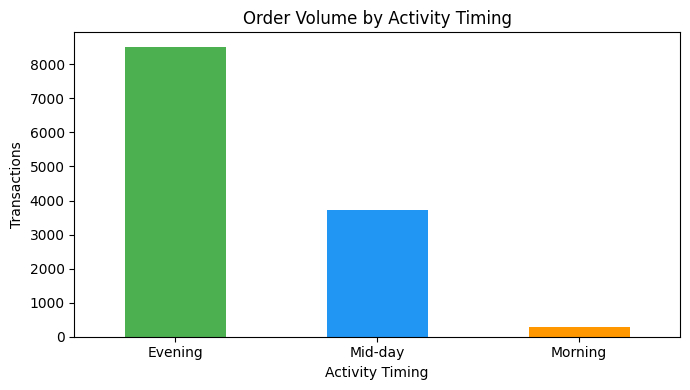

In [25]:
plt.figure(figsize=(7, 4))
df_market['Activity Timing'].value_counts().plot(
    kind='bar', color=['#4CAF50', '#2196F3', '#FF9800'])
plt.title('Order Volume by Activity Timing')
plt.ylabel('Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2c – add Item-Level Info

In [26]:
# Join Order Source and Category from df_items using the composite key
df_added = df_market.merge(
    df_items[['composite_key', 'Order Source', 'Category', 'Allergens']],
    on='composite_key', how='left'
)

print("Order source distribution:")
print(df_added['Order Source'].value_counts())
print("\nTop item categories:")
print(df_added['Category'].value_counts().head(10))


Order source distribution:
Order Source
POS    5268
Name: count, dtype: int64

Top item categories:
Category
Signature Flights       3672
Burgers & Sandwiches     425
Brunch Food              353
Entrées                  300
Desserts                 270
Salads                   248
Name: count, dtype: int64


---
## PHASE III – Building Customer Profiles

One row per customer. Six steps, then a single merge into customer_profiles.

features 
- Favourite Picks (top-3 items)  (groupby count → head(2) → join )
- Total Spending + Spending Category (sum of 'SpendingTotal' per customer)
- Preferred Activity Timing (most frequent time slot per customer)
- Avg Monthly Orders (orders per month, averaged across the period)
- Assemble 'customer_profiles' (single merge chain)
- Placeholder Birthday, Name (random seed for reproducibility)

In [27]:
# Top-3 Favourite Items per Customer 
item_counts = (df_market.groupby(['Customer ID', 'Menu Item']).size().reset_index(name='item_Counts').sort_values(['Customer ID', 'item_Counts'], ascending=[True, False]))
top3_items = (item_counts.groupby('Customer ID').head(3).groupby('Customer ID')['Menu Item'].agg(', '.join).reset_index(name='Favourite Picks'))
print("top3_items shape:", top3_items.shape)
top3_items.head()


top3_items shape: (2058, 2)


,Customer ID,Favourite Picks
0,0.0,"Frozen Margarita Flight, Ghost Rider, Elysian ..."
1,4.0,"Chicken Wing Flight, Martini Flight"
2,10.0,"Margarita Rock Flight, Taco Flight, Beer Flight"
3,12.0,"Ahi Tuna Taco Flight, Beignet Flight, Empanada..."
4,13.0,"Roasted Lemon Chicken, Side Mac n Cheese"


In [28]:
# Total Spending per Customer 
cust_spending = (df_market
    .groupby('Customer ID')['SpendingTotal'].sum().reset_index(name='TotalSpending')
)
# Customer-level spending category (based on lifetime spend, not per-transaction)
cust_spending['SpendingCategory'] = cust_spending['TotalSpending'].apply(categorize_spending)

print("Customer-level spending category distribution:")
print(cust_spending['SpendingCategory'].value_counts())
cust_spending.head()


Customer-level spending category distribution:
SpendingCategory
Premium     1751
Economy      230
Standard      77
Name: count, dtype: int64


,Customer ID,TotalSpending,SpendingCategory
0,0.0,238.79,Premium
1,4.0,121.36,Premium
2,10.0,4417.29,Premium
3,12.0,412.06,Premium
4,13.0,24.54,Economy


In [29]:
# Preferred Activity Timing 
timing_counts = (df_market
    .groupby(['Customer ID', 'Activity Timing']).size().reset_index(name='cnt')
)
preferred_timing = (timing_counts.loc[timing_counts.groupby('Customer ID')['cnt'].idxmax()][['Customer ID', 'Activity Timing']]
)
print("preferred_timing shape:", preferred_timing.shape)


preferred_timing shape: (2058, 2)


In [30]:
# Average Monthly Orders 
monthly_orders = (df_market.groupby(['Customer ID', 'Year-Month']).size().reset_index(name='Orders'))
avg_monthly = (monthly_orders.groupby('Customer ID')['Orders'].mean().reset_index(name='Avg Monthly Orders'))
print("avg_monthly shape:", avg_monthly.shape)


avg_monthly shape: (2058, 2)


In [31]:
# create profile - final step 
customer_profiles = (cust_spending.merge(preferred_timing, on='Customer ID', how='left')
    .merge(avg_monthly, on='Customer ID', how='left')
    .merge(top3_items,on='Customer ID', how='left')
)
print("customer_profiles shape:", customer_profiles.shape)

customer_profiles shape: (2058, 6)


In [32]:
# Add Placeholder - Birthday and  Name 
np.random.seed(42)
n = len(customer_profiles)
sample_names = ['Ana','Alice','James','Taylor','Casey','Harry',
                'Jamie','Drew','Cameron','Reese','Mike','Skyler','Rowan']
customer_profiles['Customer Name'] = np.random.choice(sample_names, n)
rnd_months = np.random.randint(1, 13, n)
rnd_days   = np.random.randint(1, 29, n)
customer_profiles['Birthday'] = pd.to_datetime(
    [f"2002-{m:02d}-{d:02d}" for m, d in zip(rnd_months, rnd_days)]
)


In [33]:
# redefine column order - for neatness
col_order = [
    'Customer ID', 'Customer Name', 'Birthday',
    'TotalSpending', 'SpendingCategory',
    'Activity Timing', 'Favourite Picks', 'Avg Monthly Orders'
]
customer_profiles = customer_profiles[col_order]
print("Profiles:\n")
customer_profiles.head(8)


Profiles:



,Customer ID,Customer Name,Birthday,TotalSpending,SpendingCategory,Activity Timing,Favourite Picks,Avg Monthly Orders
0,0.0,Jamie,2002-05-27,238.79,Premium,Mid-day,"Frozen Margarita Flight, Ghost Rider, Elysian ...",5.000000
1,4.0,Taylor,2002-02-02,121.36,Premium,Evening,"Chicken Wing Flight, Martini Flight",2.000000
2,10.0,Rowan,2002-08-12,4417.29,Premium,Evening,"Margarita Rock Flight, Taco Flight, Beer Flight",11.000000
3,12.0,Mike,2002-08-04,412.06,Premium,Evening,"Ahi Tuna Taco Flight, Beignet Flight, Empanada...",14.000000
4,13.0,Drew,2002-11-04,24.54,Economy,Evening,"Roasted Lemon Chicken, Side Mac n Cheese",2.000000
5,24.0,Rowan,2002-01-18,200.09,Premium,Mid-day,"Baby Back Ribs Flight, Cheesecake Flight, Empa...",2.666667
6,30.0,Casey,2002-08-15,78.14,Premium,Evening,"BBQ Pulled Pork Sandwich, Old Fashioned Flight",2.000000
7,33.0,Jamie,2002-05-19,189.16,Premium,Mid-day,"Ahi Tuna Taco Flight, BBQ Pulled Pork Sandwich...",9.000000


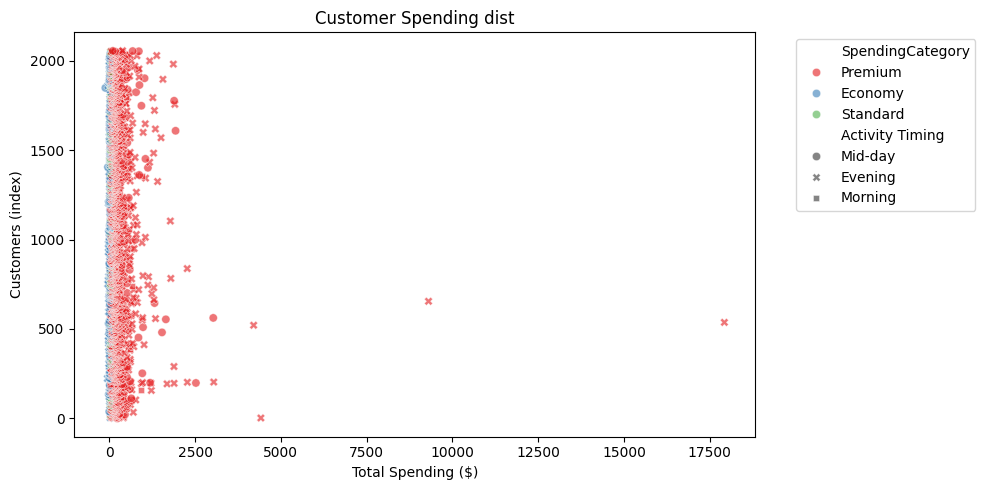

In [34]:
# plot customer spending distribution 
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=customer_profiles,
    x='TotalSpending',
    y=range(len(customer_profiles)),
    hue='SpendingCategory',
    style='Activity Timing',
    palette='Set1', alpha=0.6
)
plt.title('Customer Spending dist')
plt.xlabel('Total Spending ($)')
plt.ylabel('Customers (index)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


---
## PHASE IV – Churn Prediction via RFM Clustering

Customers are segmented into **four categories** based on RFM features:
- Segment -> Regular, occasional, New, Lost
- Recency -> low, mdeium, very lowm logm ago
- Frequency -> high, medium,  low, v low (less than 3 visits)
- chrun risk -> l,m,h


Features used :
- Recency – days since last order
- Frequency – total order count
- Order Trend – average month-over-month change in orders

In [35]:
# Build RFM features
current_date = df_market['Order Date'].max()

last_order = df_market.groupby('Customer ID')['Order Date'].max().reset_index(name='LastOrder')
freq_df    = df_market.groupby('Customer ID').size().reset_index(name='Frequency')


In [36]:
freq_df.head(5)

,Customer ID,Frequency
0,0.0,5
1,4.0,2
2,10.0,33
3,12.0,14
4,13.0,2


In [37]:

# Month-over-month order trend
mo = df_market.groupby(['Customer ID', 'Year-Month']).size().reset_index(name='Monthly Orders')
mo['Prev Month Orders'] = mo.groupby('Customer ID')['Monthly Orders'].shift(1)
mo['Order Trend']       = mo['Monthly Orders'] - mo['Prev Month Orders']
trend_df = mo.groupby('Customer ID')['Order Trend'].mean().reset_index()

rfm = (last_order.merge(freq_df, on='Customer ID').merge(trend_df, on='Customer ID')
)
rfm['Recency'] = (current_date - rfm['LastOrder']).dt.days
rfm = rfm[['Customer ID', 'Recency', 'Frequency', 'Order Trend']].fillna(0)

print("RFM feature summary:")
rfm[['Recency', 'Frequency', 'Order Trend']].describe().round(2)


RFM feature summary:


,Recency,Frequency,Order Trend
count,2058.00,2058.00,2058.00
mean,53.83,6.10,-0.05
std,34.65,7.11,2.67
min,0.00,1.00,-73.00
25%,23.00,2.00,0.00
50%,48.00,4.00,0.00
75%,84.00,7.00,0.00
max,116.00,118.00,41.00


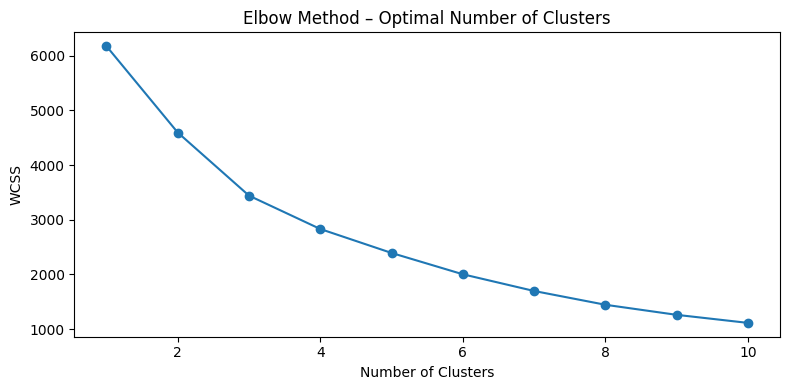

In [38]:
# Elbow method to choose k
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Order Trend']])

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method – Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.tight_layout()
plt.show()


In [39]:
# Fit KMeans (k=4) 
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Show cluster centroids in original scale to guide label assignment
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['Recency', 'Frequency', 'Order Trend']
).round(2)
centroids.index.name = 'Cluster'
print("Cluster centroids (original scale):")
print(centroids)


Cluster centroids (original scale):
         Recency  Frequency  Order Trend
Cluster                                 
0          27.15       5.49        -0.01
1          88.01       5.69         0.15
2          16.00      83.00       -73.00
3          32.68      45.36        -6.35


In [40]:
# Assign segment labels 
def assign_segment(row):
    rec, freq = row['Recency'], row['Frequency']
    if rec <= 20 and freq >= 7:
        return 'Regular'
    elif rec >= 80 and freq <= 6:
        return 'Lost'
    elif freq <= 3:
        return 'New'
    else:
        return 'Occasional'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("Segment distribution:")
print(rfm['Segment'].value_counts())


Segment distribution:
Segment
Occasional    953
New           560
Lost          394
Regular       151
Name: count, dtype: int64


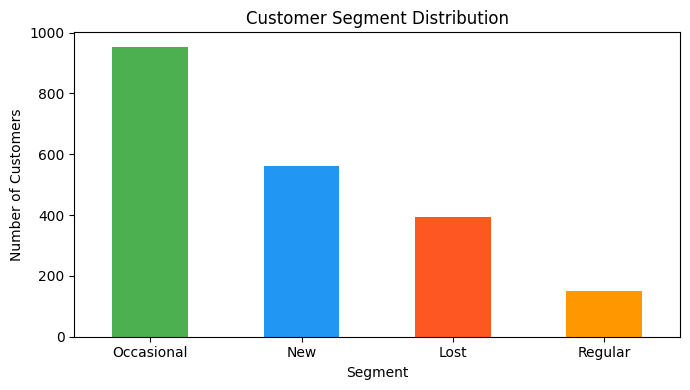

In [41]:
plt.figure(figsize=(7, 4))
rfm['Segment'].value_counts().plot(
    kind='bar', color=['#4CAF50', '#2196F3', '#FF5722', '#FF9800'])
plt.title('Customer Segment Distribution')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

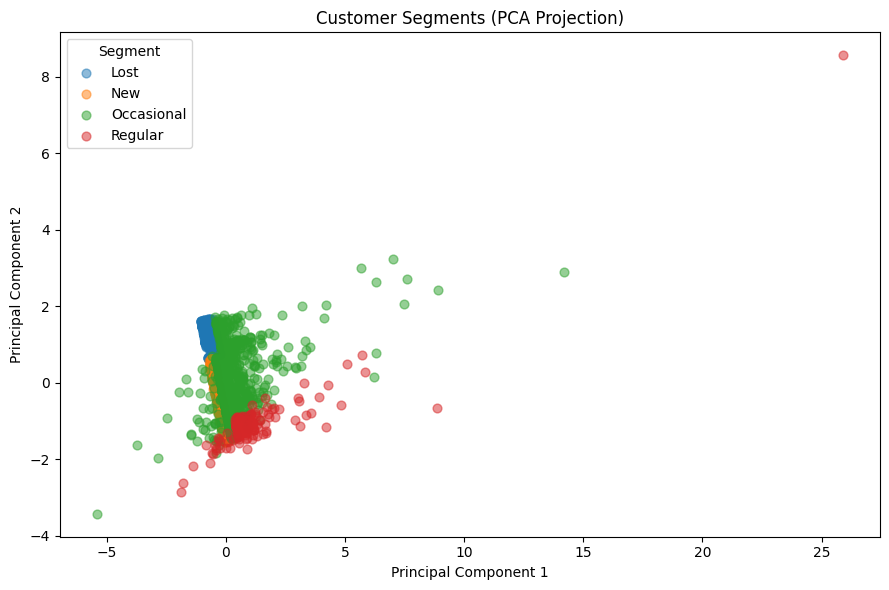

In [42]:
# PCA visualisation
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Segment': rfm['Segment']
})

plt.figure(figsize=(9, 6))
for seg, grp in pca_df.groupby('Segment'):
    plt.scatter(grp['PC1'], grp['PC2'], label=seg, alpha=0.5, s=40)
plt.title('Customer Segments (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()


In [43]:
# Merge segments back into customer_profiles 
customer_profiles = customer_profiles.merge(
    rfm[['Customer ID', 'Recency', 'Frequency', 'Order Trend', 'Segment']],
    on='Customer ID', how='left'
)

print("Final customer_profiles with churn segments:")
customer_profiles.head(8)


Final customer_profiles with churn segments:


,Customer ID,Customer Name,Birthday,TotalSpending,SpendingCategory,Activity Timing,Favourite Picks,Avg Monthly Orders,Recency,Frequency,Order Trend,Segment
0,0.0,Jamie,2002-05-27,238.79,Premium,Mid-day,"Frozen Margarita Flight, Ghost Rider, Elysian ...",5.000000,26,5,0.0,Occasional
1,4.0,Taylor,2002-02-02,121.36,Premium,Evening,"Chicken Wing Flight, Martini Flight",2.000000,46,2,0.0,New
2,10.0,Rowan,2002-08-12,4417.29,Premium,Evening,"Margarita Rock Flight, Taco Flight, Beer Flight",11.000000,5,33,0.5,Regular
3,12.0,Mike,2002-08-04,412.06,Premium,Evening,"Ahi Tuna Taco Flight, Beignet Flight, Empanada...",14.000000,20,14,0.0,Regular
4,13.0,Drew,2002-11-04,24.54,Economy,Evening,"Roasted Lemon Chicken, Side Mac n Cheese",2.000000,54,2,0.0,New
5,24.0,Rowan,2002-01-18,200.09,Premium,Mid-day,"Baby Back Ribs Flight, Cheesecake Flight, Empa...",2.666667,4,8,1.0,Regular
6,30.0,Casey,2002-08-15,78.14,Premium,Evening,"BBQ Pulled Pork Sandwich, Old Fashioned Flight",2.000000,78,2,0.0,New
7,33.0,Jamie,2002-05-19,189.16,Premium,Mid-day,"Ahi Tuna Taco Flight, BBQ Pulled Pork Sandwich...",9.000000,88,9,0.0,Occasional


## Retention Strategy 
- if Regular -> Low | Loyalty rewards; birthday emails; early access to specials 
- if Occasional -> Personalised weekend deal; highlight favourite picks
- if New -> warm Welcome ; 10% discount on next visit 
- if Lost -> Win them back -> 20% discount + strong personalisation; time-limited offer |

In [44]:
# try ollama
import requests
requests.get("http://localhost:11434").content


b'Ollama is running'

In [45]:
!"C:\Users\hp\AppData\Local\Programs\Ollama\ollama.exe" pull llama3.2

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest 
pulling dde5aa3fc5ff: 100% ▕██████████████████▏ 2.0 GB                         
pulling 966de95ca8a6: 100% ▕██████████████████▏ 1.4 KB                         
pulling fcc5a6bec9da: 100% ▕██████████████████▏ 7.7 KB                         
pulling a70ff7e570d9: 100% ▕██████████████████▏ 6.0 KB                         
pulling 56bb8bd477a5: 100% ▕██████████████████▏   96 B                         
pulling 34bb5ab01051: 100% ▕██████████████████▏  561 B                         
verifying sha256 digest 
writing manifest 
success 


In [49]:
import os
from datetime import datetime
from openai import OpenAI

OLLAMA_BASE_URL = "http://localhost:11434/v1"

ollama = OpenAI(base_url=OLLAMA_BASE_URL, api_key='ollama')

def get_customer_email(customer_id, customer_profiles, df_features):
    """
    Identifies the customer's next event and generates a tailored 
    marketing email using an LLM based on retention strategies.
    """
    # 1. Data Retrieval
    cust = customer_profiles[customer_profiles['Customer ID'] == customer_id]
    feat = df_features[df_features['Customer ID'] == customer_id]
    
    if cust.empty:
        return f"Error: Customer {customer_id} not found."

    cust = cust.iloc[0]
    segment = feat.iloc[0]['Segment'] if not feat.empty else 'Occasional'
    
    # 2. Determine Next Event (Birthday vs Holiday)
    today = datetime.now()
    year = today.year
    holidays = {
        "New Year's Day": datetime(year, 1, 1),
        "Valentine's Day": datetime(year, 2, 14),
        "St. Patrick's Day": datetime(year, 3, 17),
        "Independence Day": datetime(year, 7, 4),
        "Halloween": datetime(year, 10, 31),
        "Christmas Day": datetime(year, 12, 25),
    }
    
    bday_this_year = cust['Birthday'].replace(year=year)
    events = {**holidays, "Your Birthday": bday_this_year}
    
    future_events = {n: d for n, d in events.items() if d >= today}
    if not future_events:
        future_events = {n: d.replace(year=year+1) for n, d in events.items()}
    
    next_event = min(future_events, key=future_events.get)
    event_date = future_events[next_event].strftime('%B %d')

    # 3. Define Strategy
    strategies = {
        "Regular":    "Offer loyalty rewards, birthday specials, or early access.",
        "Occasional": "Offer a personalized weekend deal and highlight favorite picks.",
        "New":        "Give a warm welcome and a 10% discount on their next visit.",
        "Lost":       "Win them back with a 20% discount and a strong, time-limited offer."
    }
    strategy = strategies.get(segment, "Standard appreciation offer.")

    # 4. LLM Prompting
    prompt = f"""
    Write a high-conversion marketing email for a customer with the following profile:
    - Name: {cust['Customer Name']}
    - Segment: {segment}
    - Favorite Items: {cust.get('Favourite Picks', 'our top menu items')}
    - Activity Timing: {cust.get('Activity Timing', 'anytime')}
    - Upcoming Event: {next_event} on {event_date}

    Strategy to follow: {strategy}
    
    The tone should be warm, professional, and personalized. 
    Mention the upcoming {next_event} and their favorite items. 

    IMPORTANT: Do not mention 'Campbell' or any specific restaurant name. 
    Use generic terms like 'our establishment', 'our team', or 'us'.
    """

    try:
        response = ollama.chat.completions.create(
            model="llama3.2",
            messages=[
                {"role": "system", "content": "You are an expert CRM copywriter for a restaurant named xyz."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"AI Error: {str(e)}"

In [50]:

# Test with the first customer
test_id = customer_profiles['Customer ID'].iloc[0]

print(get_customer_email(test_id, customer_profiles, rfm))

Here's a high-conversion marketing email for Jamie:

**Subject: Weekend Deal Just for You, Jamie**

Dear Jamie,

As the week winds down, we can't help but think about the fantastic weekend ahead! Our team is buzzing with excitement, and we can't wait to welcome you back to our establishment.

As one of our valued Occasional guests, we want to make sure you have an unforgettable experience with us. That's why we're introducing a special weekend deal, just for you!

**Unbeatable Weekend Offer:**

* Enjoy a complimentary Frozen Margarita Flight with your meal on Saturday or Sunday
* Be the first to try our new Ghost Rider dish, a mouth-watering twist on a classic favorite
* And, to make it even sweeter, we'll include a complimentary taste of our signature Elysian Space Dust dessert

**St. Patrick's Day Celebration:**

Mark your calendars, Jamie! We're getting into the festive spirit, and we can't wait to celebrate with you on St. Patrick's Day, March 17! Join us for a special lunch or din

In [58]:
# print the customer profile for reference
customer_profiles[customer_profiles['Customer ID'] == test_id]

,Customer ID,Customer Name,Birthday,TotalSpending,SpendingCategory,Activity Timing,Favourite Picks,Avg Monthly Orders,Recency,Frequency,Order Trend,Segment
0,0.0,Jamie,2002-05-27,238.79,Premium,Mid-day,"Frozen Margarita Flight, Ghost Rider, Elysian ...",5.0,26,5,0.0,Occasional
